In [2482]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime

#from tensorflow.keras.models import Model
#from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
# from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, roc_auc_score

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns
import datetime

LSTM

In [2483]:
start = "2006-01-01"
end = datetime.date.today()

# Create synthetic portfolio dataset
ASSETS = [
    "AAPL",   # equity
    "MSFT",   # equity
    "SPY",    # equity index
    "TLT",    # bonds
    "IEF",    # bonds
    "GLD",    # gold
    "USO",    # oil
    "VNQ",    # REIT
    "QQQ",   # volatility index
    "DBC"     # commodities
]

def get_returns(assets, start, end):
    failed_tickers = []

    # Download data
    prices = yf.download(assets, start=start, end=end, group_by='ticker', auto_adjust=True)

    # Prepare adjusted close DataFrame
    adj_close = pd.DataFrame()

    if isinstance(prices.columns, pd.MultiIndex):
        # Multi-ticker download
        for ticker in assets:
            if ticker in prices.columns.get_level_values(0):
                adj_close[ticker] = prices[ticker]['Close']
            else:
                failed_tickers.append(ticker)
    else:
        # Single ticker
        ticker = assets[0] if isinstance(assets, list) else assets
        if 'Close' in prices.columns:
            adj_close[ticker] = prices['Close']
        else:
            print(ticker, " failed download")
            failed_tickers.append(ticker)

    # Compute log returns
    returns = np.log(adj_close / adj_close.shift(1))

    # Drop NaNs and inf values 
    returns = returns.replace([np.inf, -np.inf], np.nan).dropna()

    return returns, failed_tickers

In [3166]:
# Generate LSTM dataset: synthetic portfolio
np.random.seed(4265)

def generate_sparse_weights(n_assets, k=10, alpha=0.3):
    weights = np.zeros(n_assets)
    # Pick k assets to have significant weight
    selected = np.random.choice(n_assets, k, replace=False)
    rand_weights = np.random.dirichlet([alpha]*k)
    weights[selected] = rand_weights

    # Give small random weight to other assets
    remaining_idx = [i for i in range(n_assets) if i not in selected]
    weights[remaining_idx] = np.random.dirichlet([0.05]*len(remaining_idx)) * 0.01  

    # Normalize weights
    weights /= weights.sum()
    return weights

def create_lstm_dataset(returns, n_portfolios=500, window=60, horizon=10):
    X, y_vol, y_dir = [], [], []
    #weights = generate_sparse_weights(returns.shape[1], k=10)

    #port_returns = returns.values @ weights

    for _ in range(n_portfolios):
        weights = generate_sparse_weights(returns.shape[1], k=10)
        port_returns = returns.values @ weights

        for i in range(0, len(port_returns) - window - horizon, window):

            past_window = port_returns[i:i+window]

            mean = port_returns[:i+window].mean()
            std = port_returns[:i+window].std() + 1e-8

            #mean = np.mean(past_window)
            #std = np.std(past_window) + 1e-8
            past_window = past_window / std

            future_window = port_returns[i+window:i+window+horizon]

            future_vol = np.std(future_window) * np.sqrt(252)
            future_return = np.sum(future_window)

            # adaptive threshold 
            hist_vol = np.std(port_returns[:i+window])
            threshold = hist_vol * np.sqrt(horizon) * 0.7

            if future_return > threshold:
                direction = 1
            elif future_return < -threshold:
                direction = 0
            else:
                continue

            X.append(past_window)
            y_vol.append(future_vol)
            y_dir.append(direction)

    X = np.array(X).reshape(-1, window, 1)
    y_vol = np.array(y_vol)
    y_dir = np.array(y_dir)

    return X, y_vol, y_dir

In [3167]:
returns, prices = get_returns(ASSETS, start=start, end=end)

split_idx = int(len(returns) * 0.8)

split_idx2 = int(len(returns) * 0.9)

train_returns = returns.iloc[:split_idx]
val_returns = returns.iloc[split_idx:split_idx2 ]
test_returns = returns.iloc[split_idx2: ]


X_train, yv_train, yd_train  = create_lstm_dataset(train_returns)
X_valid, yv_valid, yd_valid = create_lstm_dataset(val_returns)
X_test, yv_test, yd_test  = create_lstm_dataset(test_returns)


[*********************100%***********************]  10 of 10 completed


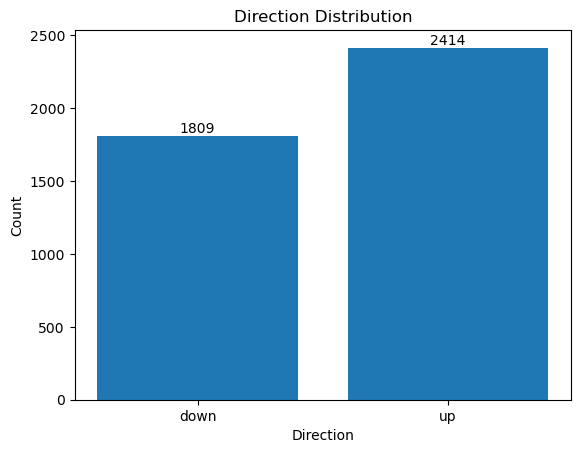

In [3168]:
# Check for class imbalance in synthetic dataset
unique, counts = np.unique(yd_train, return_counts=True)

labels_map = {0: 'down', 1: 'up'}
labels = [labels_map[u] for u in unique]

plt.bar(labels, counts)
plt.title("Direction Distribution")
plt.xlabel("Direction")
plt.ylabel("Count")

for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [3169]:
# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_valid = torch.tensor(X_valid, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)

yv_train = torch.tensor(yv_train, dtype=torch.float32).view(-1, 1)
yv_valid = torch.tensor(yv_valid, dtype=torch.float32).view(-1, 1)
yv_test  = torch.tensor(yv_test,  dtype=torch.float32).view(-1, 1)

yd_train = torch.tensor(yd_train, dtype=torch.float32).view(-1, 1)
yd_valid = torch.tensor(yd_valid, dtype=torch.float32).view(-1, 1)
yd_test  = torch.tensor(yd_test,  dtype=torch.float32).view(-1, 1)

class PortfolioDataset(Dataset):
    def __init__(self, X, y_vol, y_dir):
        self.X = X
        self.y_vol = y_vol
        self.y_dir = y_dir

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_vol[idx], self.y_dir[idx]


# Create Datasets
train_dataset = PortfolioDataset(X_train, yv_train, yd_train)
valid_dataset = PortfolioDataset(X_valid, yv_valid, yd_valid)
test_dataset = PortfolioDataset(X_test, yv_test, yd_test)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [3170]:
print("Unique yd_train:", torch.unique(yd_train))
print("Sample yd_train:", yd_train[:10])

Unique yd_train: tensor([0., 1.])
Sample yd_train: tensor([[1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.]])


In [4025]:
# Regression loss
mse_loss = nn.MSELoss()
y_neg = yd_train[yd_train == 0]
y_pos = yd_train[yd_train == 1]
pos_weight = torch.tensor([len(y_neg) / len(y_pos)])

bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
#bce_loss = nn.BCEWithLogitsLoss()

In [3415]:
# LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size1=128, hidden_size2=64):
        super(LSTMModel, self).__init__()

        # LSTM layers
        self.lstm1 = nn.LSTM(input_size, hidden_size1, batch_first=True)
        self.dropout1 = nn.Dropout(0.1)

        self.lstm2 = nn.LSTM(hidden_size1, hidden_size2, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)

        # Output heads
        self.volatility_head = nn.Linear(hidden_size2, 1)   # regression
        self.direction_head = nn.Sequential(
            nn.Linear(hidden_size2, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )   # binary classification

    def forward(self, x):
        # x: (batch, seq_len, input_size)

        out, _ = self.lstm1(x)
        out = self.dropout1(out)

        out, _ = self.lstm2(out)

        # Take last timestep
        out = out[:, -1, :]
        out = self.dropout2(out)

        vol_output = torch.nn.functional.softplus(self.volatility_head(out))
        dir_output = self.direction_head(out)  

        return vol_output, dir_output

In [3828]:
model = LSTMModel(input_size = X_train.shape[2])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

In [3829]:
threshold = 0.5

In [3830]:
all_preds = []
all_targets = []
all_probs = []

def evaluate(model, loader, mse_loss, bce_loss):
    model.eval()

    total_loss = 0
    total_vol_loss = 0
    total_dir_loss = 0
    total_mae = 0

    with torch.no_grad():
        for x, y_vol, y_dir in loader:
            x = x.to(device)
            y_vol = y_vol.to(device)
            y_dir = y_dir.to(device)
            
            vol_pred, dir_pred = model(x)
            #print("Logits std:", dir_pred.std().item())

            y_dir = y_dir.view(-1, 1)

            loss_vol = mse_loss(vol_pred, y_vol)
            loss_dir = bce_loss(dir_pred, y_dir)

            alpha = 0.4  # vol
            beta = 0.6   # dir

            loss = 60*loss_vol + loss_dir

            mae = torch.mean(torch.abs(vol_pred - y_vol))

            # Apply sigmoid before threshold
            probs = torch.sigmoid(dir_pred)
            preds = (probs > threshold).float()

            # check mean probs
            print("Mean prob:", probs.mean().item())
            print(probs.min().item(), probs.max().item())
            print("Predicted positives:", preds.sum().item())
            print("Actual positives:", y_dir.sum().item())

            all_preds.extend(dir_pred.view(-1).cpu().numpy())
            all_targets.extend(y_dir.view(-1).cpu().numpy())
            all_probs.extend(probs.view(-1).cpu().numpy())  

            total_loss += loss.item()
            total_vol_loss += loss_vol.item()
            total_dir_loss += loss_dir.item()
            total_mae += mae.item()

    auc = roc_auc_score(all_targets, all_probs)

    n = len(loader)
    return {
        "loss": total_loss / n,
        "vol_loss": total_vol_loss / n,
        "dir_loss": total_dir_loss / n,
        "mae": total_mae / n,
        "auc": auc,
    }

In [3831]:
train_loss =  []
val_loss = []
train_vol_loss = []
val_vol_loss = []
train_dir_loss = [] 
val_dir_loss = []
train_mae = []
val_mae = []
train_auc = []
val_auc = []

def train(model, train_loader, val_loader, epochs, optimizer, mse_loss, bce_loss):
    best_val_loss = float('inf')
    patience_counter = 0
    patience = 3
    trained_epochs = 0
    
    with torch.no_grad():
        x, y_vol, y_dir = next(iter(train_loader))
        vol_pred, dir_pred = model(x)
        y_dir = y_dir.view(-1, 1)

        init_vol_loss = mse_loss(vol_pred, y_vol).item()
        init_dir_loss = bce_loss(dir_pred, y_dir).item()

    for epoch in range(epochs):
        model.train()

        for x, y_vol, y_dir in train_loader:
            x = x.to(device)
            y_vol = y_vol.to(device)
            y_dir = y_dir.to(device)
            optimizer.zero_grad()

            vol_pred, dir_pred = model(x)

            # Ensure shape consistency
            y_dir = y_dir.view(-1, 1)

            loss_vol = mse_loss(vol_pred, y_vol)
            loss_dir = bce_loss(dir_pred, y_dir)

            dir_loss_norm = loss_dir / init_dir_loss
            vol_loss_norm = loss_vol / init_vol_loss

            alpha = 0.4  # vol
            beta = 0.6   # dir

            #loss = alpha * dir_loss_norm + beta * vol_loss_norm
            loss = 60 *loss_vol + loss_dir

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # to try commenting
            optimizer.step()

        # Evaluate
        train_metrics = evaluate(model, train_loader, mse_loss, bce_loss)
        val_metrics   = evaluate(model, val_loader, mse_loss, bce_loss)
        scheduler.step(val_metrics['loss'])
        
        # For plots
        train_loss.append(train_metrics['loss'])
        val_loss.append(val_metrics['loss'])
        train_vol_loss.append(train_metrics['vol_loss'])
        val_vol_loss.append(val_metrics['vol_loss'])
        train_dir_loss.append(train_metrics['dir_loss'])
        val_dir_loss.append(val_metrics['dir_loss'])
        train_mae.append(train_metrics['mae'])
        val_mae.append(val_metrics['mae'])
        train_auc.append(train_metrics['auc'])
        val_auc.append(val_metrics['auc'])

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train total Loss: {train_metrics['loss']:.4f} | Val total Loss: {val_metrics['loss']:.4f}")
        print(f"Train vol Loss: {train_metrics['vol_loss']:.4f} | Val vol Loss: {val_metrics['vol_loss']:.4f}")
        print(f"Train AUC: {train_metrics['auc']:.4f} | Val AUC: {val_metrics['auc']:.4f}")

        trained_epochs += 1
        # Early stopping
        current_val_loss = val_metrics['loss']
        min_delta = 1e-4

        if current_val_loss < best_val_loss - min_delta:
            best_val_loss = current_val_loss
            patience_counter = 0

            # save best model
            best_model_state = model.state_dict()

        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            EPOCHS = epoch+1
            break
    return trained_epochs, best_model_state

        

In [3832]:
EPOCHS = 20
trained_epochs, best_model_state = train(model, train_loader, val_loader, EPOCHS, optimizer, mse_loss, bce_loss)

# Save the model state_dict
torch.save(best_model_state, 'model_weights.pth')

Mean prob: 0.4951411187648773
0.4945763349533081 0.4958912134170532
Predicted positives: 0.0
Actual positives: 31.0
Mean prob: 0.4951390326023102
0.4946162700653076 0.49585071206092834
Predicted positives: 0.0
Actual positives: 33.0
Mean prob: 0.4951884150505066
0.4946785867214203 0.4958069324493408
Predicted positives: 0.0
Actual positives: 36.0
Mean prob: 0.4951495826244354
0.49471667408943176 0.495899498462677
Predicted positives: 0.0
Actual positives: 36.0
Mean prob: 0.49510830640792847
0.49464282393455505 0.495754599571228
Predicted positives: 0.0
Actual positives: 32.0
Mean prob: 0.4951987564563751
0.4945395886898041 0.4958759844303131
Predicted positives: 0.0
Actual positives: 43.0
Mean prob: 0.49517709016799927
0.49448710680007935 0.49588313698768616
Predicted positives: 0.0
Actual positives: 37.0
Mean prob: 0.49515974521636963
0.4947660565376282 0.4958820044994354
Predicted positives: 0.0
Actual positives: 38.0
Mean prob: 0.4951443672180176
0.4946836531162262 0.495897620916366

In [3833]:
print(train_loss)

[1.0618528777902776, 0.9525990847385291, 0.9270561635494232, 0.8152676838817019, 0.7303433833700238, 0.6167631018342394, 0.5854869033351089]


In [3834]:
print(val_loss)

[1.6261840408498591, 1.4425472237847068, 1.458330598744479, 1.4193914478475398, 1.6806244416670366, 1.8847263726321133, 2.1031455018303613]


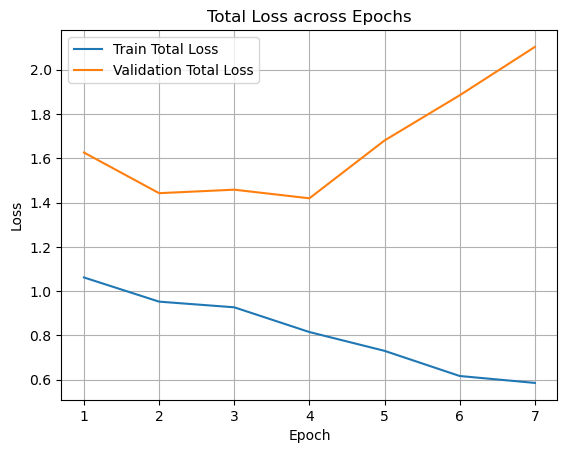

In [3835]:
# Plot loss over epochs
plt.figure()
plt.plot(range(1, len(train_loss)+1), train_loss, label='Train Total Loss')
plt.plot(range(1, len(val_loss)+1), val_loss, label='Validation Total Loss')
plt.title('Total Loss across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

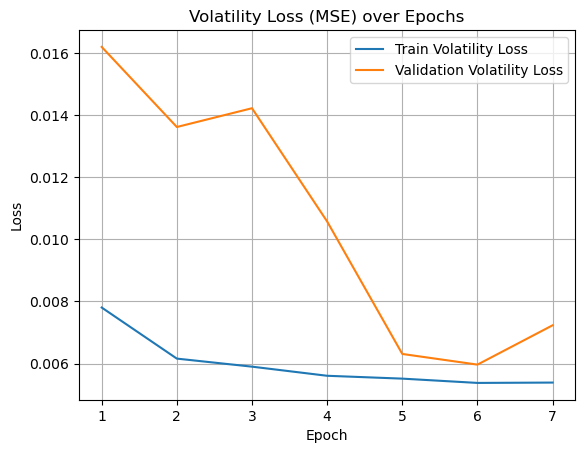

In [3836]:
# Plot volatility MSE over epochs
plt.figure()
plt.plot(range(1, len(train_vol_loss)+1),train_vol_loss, label='Train Volatility Loss')
plt.plot(range(1, len(val_vol_loss)+1),val_vol_loss, label='Validation Volatility Loss')
plt.title('Volatility Loss (MSE) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

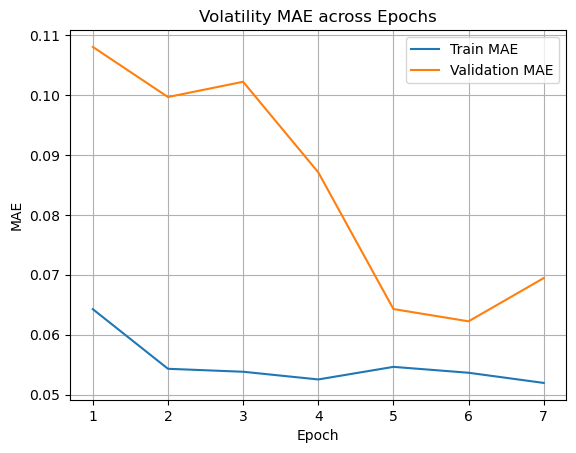

In [3837]:
# PLot volatility MAE across epochs
plt.figure()
plt.plot(range(1, len(train_mae)+1), train_mae, label='Train MAE')
plt.plot(range(1, len(val_mae)+1), val_mae, label='Validation MAE')
plt.title('Volatility MAE across Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.grid(True)
plt.legend()
plt.show()


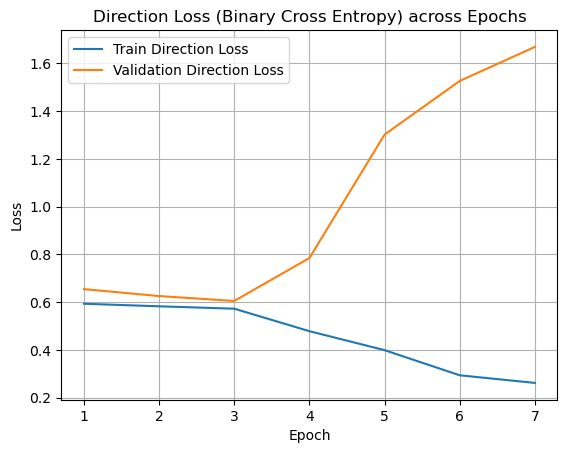

In [3838]:
# PLot Binary Cross Entropy Loss
plt.figure()
plt.plot(range(1, len(train_dir_loss)+1),train_dir_loss, label='Train Direction Loss')
plt.plot(range(1, len(val_dir_loss)+1),val_dir_loss, label='Validation Direction Loss')
plt.title('Direction Loss (Binary Cross Entropy) across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

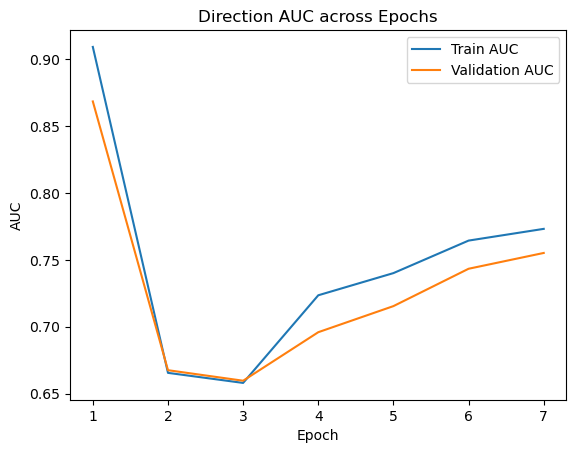

In [3839]:
# Plot direction AUC across epochs 
plt.figure()
plt.plot(range(1, len(train_auc)+1),train_auc, label='Train AUC')
plt.plot(range(1, len(val_auc)+1),val_auc, label='Validation AUC')
plt.title('Direction AUC across Epochs')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.show()

In [ ]:
# Future volatility of portfolio
def calculate_future_risk(model, tickers_weights_dictionary):
    X_input = portfolio_to_lstm_input(tickers_weights_dictionary)

    vol_pred, dir_pred = model.predict(X_input)

    vol = vol_pred[0][0] 

    prob_up = dir_pred[0][0]

    direction = "Up" if prob_up > threshold else "Down"

    # Confidence = probability distance from 0.5
    confidence = abs(prob_up - threshold) * 2   # scaled to [0,1]

    return {
        "predicted_volatility": vol,
        "predicted_direction": direction,
        "confidence": confidence,
        "prob_up": prob_up
    }

In [3841]:
all_preds = []
all_targets = []
all_probs = []
test_metrics = evaluate(model, test_loader, mse_loss, bce_loss)

Mean prob: 0.2182898372411728
0.05447648838162422 0.911080539226532
Predicted positives: 9.0
Actual positives: 29.0
Mean prob: 0.28219470381736755
0.05597372725605965 0.9332243204116821
Predicted positives: 11.0
Actual positives: 28.0
Mean prob: 0.1830882877111435
0.05744784697890282 0.8937528729438782
Predicted positives: 5.0
Actual positives: 30.0
Mean prob: 0.25110068917274475
0.05596866086125374 0.9428332448005676
Predicted positives: 11.0
Actual positives: 25.0
Mean prob: 0.22058939933776855
0.055564574897289276 0.9125096201896667
Predicted positives: 4.0
Actual positives: 18.0


In [3842]:
print("Test set Volatility Evaluation:")
print(f"Test MSE: {test_metrics['vol_loss']:.4f}")
print(f"Test MAE: {test_metrics['mae']:.4f}")

print("Test set Direction Evaluation:")
print(f"Test AUC: {test_metrics['auc']:.4f}")

Test set Volatility Evaluation:
Test MSE: 0.0020
Test MAE: 0.0345
Test set Direction Evaluation:
Test AUC: 0.4424


Confusion Matrix:
[[162   1]
 [102  28]]


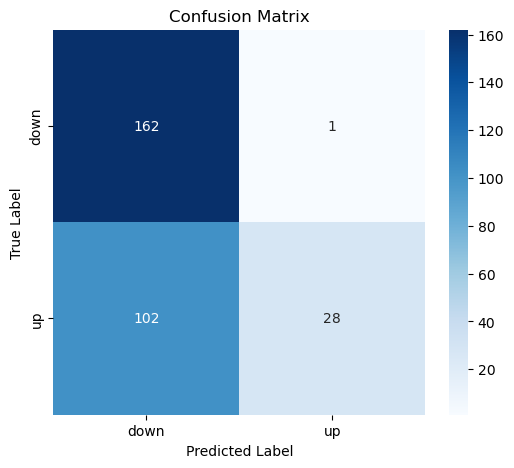

In [3843]:
# Convert probabilities to 0/1
y_dir_pred_class = (np.array(all_preds) > threshold).astype(int)

# print(np.unique(yd_test))

# Confusion matrix
cm = confusion_matrix(yd_test, y_dir_pred_class)
print("Confusion Matrix:")
print(cm)

labels = ['down', 'up']
plt.figure(figsize=(6,5))
sns.heatmap(
   cm,
   annot=True,
   fmt="d",
   cmap="Blues",
   xticklabels=labels,
   yticklabels=labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [3844]:
# Classification Report

report = classification_report(yd_test, y_dir_pred_class, target_names=["Down", "Up"])
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

        Down       0.61      0.99      0.76       163
          Up       0.97      0.22      0.35       130

    accuracy                           0.65       293
   macro avg       0.79      0.60      0.56       293
weighted avg       0.77      0.65      0.58       293



Evaluating performance of Agentic tools on synthetic portfolios

In [3845]:
# Helper: Fetch price data
# "start": "2020-01-01", "end": "today"

start = "2020-01-01"
end = "2026-03-30"
def get_price_data(tickers, start=start, end=end):
    data = yf.download(
        tickers,
        start=start,
        end=end,
        auto_adjust=True  # ensures adjusted prices
    )

    # Case 1: MultiIndex (multiple tickers)
    if isinstance(data.columns, pd.MultiIndex):
        if "Close" in data.columns.get_level_values(0):
            data = data["Close"]
        else:
            raise ValueError("Close prices not found in data")

    # Case 2: Single ticker
    else:
        if "Close" in data.columns:
            data = data[["Close"]]
        else:
            raise ValueError("Close column not found")

    return data.dropna()


# Calculate Risk Metrics

# Normalization
def clamp(x, min_val=0, max_val=1):
    return max(min(x, max_val), min_val) 

def calculate_risk_metrics(tickers_weights_dictionary):
    tickers = list(tickers_weights_dictionary.keys())
    weights = np.array(list(tickers_weights_dictionary.values()))

    # Normalize weights 
    weights = weights / np.sum(weights)

    prices = get_price_data(tickers)
    returns = prices.pct_change().dropna()

    # Portfolio returns
    portfolio_returns = returns.dot(weights)

    # ---- Metrics ----
    # Volatility (annualized)
    volatility = np.std(portfolio_returns) * np.sqrt(252)

    # VaR (95% confidence)
    VaR = np.percentile(portfolio_returns, 5)

    # Sharpe Ratio (assume risk-free rate = 0)
    sharpe = np.mean(portfolio_returns) / np.std(portfolio_returns) * np.sqrt(252)

    # Max Drawdown
    cumulative = (1 + portfolio_returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_drawdown = drawdown.min()

    # Correlation (average pairwise correlation)
    corr_matrix = returns.corr()
    avg_corr = corr_matrix.values[np.triu_indices_from(corr_matrix, k=1)].mean()

    # Concentration (Herfindahl index)
    concentration = np.sum(weights**2)

    # Normalization (bounded 0–1) 
    vol_norm = clamp(volatility / 0.4)

    var_norm = clamp(abs(VaR) / 0.1)

    # Sharpe: map inversely without clamping to 0
    sharpe_norm = clamp(max(0.5 - sharpe/4, 0), 0, 1)

    conc_norm = clamp(concentration)

    # Correlation: map from [-1, 1] to [0, 1]
    corr_norm = clamp((avg_corr + 1) / 2)

    # Include drawdown
    dd_norm = clamp(abs(max_drawdown) / 0.5)

    metrics = {
        "vol_norm": vol_norm,
        "var_norm": var_norm,
        "sharpe_norm": sharpe_norm,
        "conc_norm": conc_norm,
        "corr_norm": corr_norm,
        "dd_norm": dd_norm,
        # Raw metrics
        "raw": {
            "volatility": volatility,
            "VaR": VaR,
            "sharpe": sharpe,
            "max_drawdown": max_drawdown,
            "correlation": avg_corr,
            "concentration": concentration
        }
    }

    return metrics


# Risk classification Function
def classify_risk_level(tickers_weights_dictionary):

    metrics = calculate_risk_metrics(tickers_weights_dictionary)

    risk_score = (
        0.25 * metrics["vol_norm"] +
        0.15 * metrics["var_norm"] +
        0.10 * metrics["sharpe_norm"] +
        0.15 * metrics["conc_norm"] +
        0.15 * metrics["corr_norm"] +
        0.20 * metrics["dd_norm"]
    )

    if risk_score < 0.35:
        volatility_label = "Low"
    elif risk_score <= 0.60:
        volatility_label = "Medium"
    else:
        volatility_label = "High"

    return {
        "risk_score": risk_score,
        "risk_level": volatility_label,
        "metrics": metrics
    }

Testing current portfolio risk tool on synthetic portfolios:
- balanced portfolio that is diversified
- aggressive portfolio that is tech focused

In [3846]:
portfolio_balanced = {
    "AAPL":0.20,
    "MSFT":0.20, 
    "SPY": 0.20, 
    "TLT":0.15, 
    "GLD":0.15, 
    "VNQ":0.10
}
results = classify_risk_level(portfolio_balanced)

[*********************100%***********************]  6 of 6 completed


In [3847]:
results

{'risk_score': 0.3769039189733815,
 'risk_level': 'Medium',
 'metrics': {'vol_norm': 0.4129631496852416,
  'var_norm': 0.15821438076897018,
  'sharpe_norm': 0.2794494387048156,
  'conc_norm': 0.17499999999999993,
  'corr_norm': 0.6492128083815243,
  'dd_norm': 0.49177054654507657,
  'raw': {'volatility': 0.16518525987409666,
   'VaR': -0.01582143807689702,
   'sharpe': 0.8822022451807376,
   'max_drawdown': -0.24588527327253829,
   'correlation': 0.29842561676304846,
   'concentration': 0.17499999999999993}}}

In [3848]:
portfolio_aggressive = {
    "AAPL":0.20, 
    "MSFT":0.20, 
    "QQQ":0.25, 
    "NVDA":0.20, 
    "TSLA":0.15
}
results2 = classify_risk_level(portfolio_aggressive)

[*********************100%***********************]  5 of 5 completed


In [3849]:
results2

{'risk_score': 0.6107008743846791,
 'risk_level': 'High',
 'metrics': {'vol_norm': 0.8384899435844984,
  'var_norm': 0.3249280115944271,
  'sharpe_norm': 0.21206417592641374,
  'conc_norm': 0.20500000000000002,
  'corr_norm': 0.8203550688150045,
  'dd_norm': 0.8866475441724925,
  'raw': {'volatility': 0.33539597743379934,
   'VaR': -0.03249280115944271,
   'sharpe': 1.151743296294345,
   'max_drawdown': -0.44332377208624624,
   'correlation': 0.6407101376300091,
   'concentration': 0.20500000000000002}}}

In [ ]:
def portfolio_to_lstm_input(portfolio, window=60):
       tickers = portfolio["tickers"]
       weights = np.array(portfolio["weights"], dtype=float)


       # Normalize weights (handles % like 50,30,20)
       weights = weights / weights.sum()


       # Convert to dict format 
       tickers_weights = dict(zip(tickers, weights))

       # Fetch + compute
       prices = get_returns(tickers,
           start="2020-01-01",
           end="2026-03-30"
       )


       # If get_price_data is returning a tuple
       if isinstance(prices, tuple):
           prices = prices[0]  # Take only the DataFrame
       returns = prices[tickers]
       portfolio_returns = returns.dot(weights)

       recent_window = portfolio_returns[-window:]


       # Normalize
       recent_window = (
           recent_window - np.mean(recent_window)
               ) / (np.std(recent_window) + 1e-8)
  
       X_input = recent_window.to_numpy().reshape(1, window, 1)


       return X_input


  
threshold = 0.5
def future_portfolio_risk(portfolio):
  
   all_preds = []
   all_targets = []
   all_probs = []
   # Ensure input is tensor
   X_input = portfolio_to_lstm_input(portfolio, window=60)
   if not torch.is_tensor(X_input):
       X_input = torch.tensor(X_input, dtype=torch.float32)
      
   # Load the saved state_dict
   model = LSTMModel(input_size=1)
   model.load_state_dict(torch.load('model_weights.pth'))


   # Set the model to
   model.eval()
   with torch.no_grad():
       vol_pred, dir_pred = model(X_input)
      
       vol = vol_pred
       y_dir = dir_pred.view(-1, 1)


       # Apply sigmoid before threshold
       prob_up = torch.sigmoid(dir_pred)
       preds = (prob_up > threshold).float()


       print(preds)
       direction = ["Up" if p==1.0 else "Down" for p in preds.view(-1).tolist()]


   # Confidence = probability distance from 0.5
   confidence = abs(prob_up - 0.5) * 2   # scaled to [0,1]

   # Convert tensors to plain Python types
   vol_value = vol_pred.item()          
   prob_up_value = prob_up.item()        
   confidence_value = confidence.item()  

   return {
       "predicted_volatility": vol_value,
       "predicted_direction": direction,
       "confidence": confidence_value,
       "prob_up": prob_up_value
   }


In [3851]:
portfolio_balanced = {
"tickers": ["AAPL", "MSFT", "SPY", "TLT", "GLD", "VNQ"],
"weights": [0.20, 0.20, 0.20, 0.15, 0.15, 0.10]
}

portfolio_aggressive = {
"tickers": ["AAPL", "MSFT", "QQQ", "NVDA", "TSLA"],
"weights": [0.20, 0.20, 0.25, 0.20, 0.15]
}


In [3989]:
balanced_r = future_portfolio_risk(portfolio_balanced)
aggressive_r = future_portfolio_risk(portfolio_aggressive)

[*********************100%***********************]  6 of 6 completed
[**********************80%*************          ]  4 of 5 completed

tensor([[0.]])


[*********************100%***********************]  5 of 5 completed

tensor([[0.]])


In [3853]:
def actual_portfolio_returns(portfolio, window=60):
    tickers = portfolio["tickers"]
    weights = np.array(portfolio["weights"], dtype=float)
    weights /= weights.sum()
    
    prices, failed_tickers = get_returns(tickers, start="2020-01-01", end="2026-03-30")
    returns = prices[tickers]
    portfolio_returns = returns.dot(weights)
    
    return portfolio_returns

In [3854]:
def actual_volatility(portfolio, window=10):
    portfolio_returns = actual_portfolio_returns(portfolio)
    recent_window = portfolio_returns[-window:]
    
    vol = np.std(recent_window) * np.sqrt(252)
    return vol

In [3855]:
actual_vol = actual_volatility(portfolio_balanced)
print(f"Predicted Vol: {balanced_r['predicted_volatility']:.4f}, Actual Vol: {actual_vol:.4f}")
print(f"Diff in vol: {np.abs(balanced_r['predicted_volatility']-actual_vol)/balanced_r['predicted_volatility'] * 100:.4f}%")

[*********************100%***********************]  6 of 6 completed

Predicted Vol: 0.1328, Actual Vol: 0.1468
Diff in vol: 10.5261%


In [3856]:
def actual_direction(portfolio, horizon=10):
    portfolio_returns = actual_portfolio_returns(portfolio)
    # direction of the most recent return
    last_return = portfolio_returns.iloc[-10:]
    #print(last_return)
    last_return = np.sum(last_return)
    return "Up" if last_return > 0 else "Down"

In [3857]:
actual_dir = actual_direction(portfolio_balanced)
print(f"Predicted Direction: {balanced_r['predicted_direction']}, Actual Direction: {actual_dir}")

[*********************100%***********************]  6 of 6 completed

Predicted Direction: ['Up'], Actual Direction: Down


# Better Model experiment

In [4026]:
model2 = LSTMModel(input_size = X_train.shape[2])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2.to(device)
optimizer = torch.optim.Adam(model2.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

In [4027]:
all_preds = []
all_targets = []
all_probs = []

def evaluate(model, loader, mse_loss, bce_loss):
    model.eval()

    total_loss = 0
    total_vol_loss = 0
    total_dir_loss = 0
    total_mae = 0

    with torch.no_grad():
        for x, y_vol, y_dir in loader:
            x = x.to(device)
            y_vol = y_vol.to(device)
            y_dir = y_dir.to(device)
            
            vol_pred, dir_pred = model(x)
            #print("Logits std:", dir_pred.std().item())

            y_dir = y_dir.view(-1, 1)

            loss_vol = mse_loss(vol_pred, y_vol)
            loss_dir = bce_loss(dir_pred, y_dir)

            alpha = 0.4  # vol
            beta = 0.6   # dir

            loss = loss_vol + loss_dir

            mae = torch.mean(torch.abs(vol_pred - y_vol))

            # Apply sigmoid before threshold
            probs = torch.sigmoid(dir_pred)
            preds = (probs > threshold).float()

            # check mean probs
            #print("Mean prob:", probs.mean().item())
            #print(probs.min().item(), probs.max().item())
            #print("Predicted positives:", preds.sum().item())
            #print("Actual positives:", y_dir.sum().item())

            all_preds.extend(dir_pred.view(-1).cpu().numpy())
            all_targets.extend(y_dir.view(-1).cpu().numpy())
            all_probs.extend(probs.view(-1).cpu().numpy())  

            total_loss += loss.item()
            total_vol_loss += loss_vol.item()
            total_dir_loss += loss_dir.item()
            total_mae += mae.item()

    auc = roc_auc_score(all_targets, all_probs)

    n = len(loader)
    return {
        "loss": total_loss / n,
        "vol_loss": total_vol_loss / n,
        "dir_loss": total_dir_loss / n,
        "mae": total_mae / n,
        "auc": auc,
    }

In [4028]:
train_loss =  []
val_loss = []
train_vol_loss = []
val_vol_loss = []
train_dir_loss = [] 
val_dir_loss = []
train_mae = []
val_mae = []
train_auc = []
val_auc = []

def train(model, train_loader, val_loader, epochs, optimizer, mse_loss, bce_loss):
    best_val_loss = float('inf')
    patience_counter = 0
    patience = 2
    trained_epochs = 0
    
    with torch.no_grad():
        x, y_vol, y_dir = next(iter(train_loader))
        vol_pred, dir_pred = model(x)
        y_dir = y_dir.view(-1, 1)

        init_vol_loss = mse_loss(vol_pred, y_vol).item()
        init_dir_loss = bce_loss(dir_pred, y_dir).item()

    for epoch in range(epochs):
        model.train()

        for x, y_vol, y_dir in train_loader:
            x = x.to(device)
            y_vol = y_vol.to(device)
            y_dir = y_dir.to(device)
            optimizer.zero_grad()

            vol_pred, dir_pred = model(x)

            # Ensure shape consistency
            y_dir = y_dir.view(-1, 1)

            loss_vol = mse_loss(vol_pred, y_vol)
            loss_dir = bce_loss(dir_pred, y_dir)

            dir_loss_norm = loss_dir / init_dir_loss
            vol_loss_norm = loss_vol / init_vol_loss

            alpha = 0.4  # vol
            beta = 0.6   # dir

            #loss = alpha * dir_loss_norm + beta * vol_loss_norm
            loss = loss_vol + loss_dir

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # to try commenting
            optimizer.step()

        # Evaluate
        train_metrics = evaluate(model, train_loader, mse_loss, bce_loss)
        val_metrics   = evaluate(model, val_loader, mse_loss, bce_loss)
        scheduler.step(val_metrics['loss'])
        
        # For plots
        train_loss.append(train_metrics['loss'])
        val_loss.append(val_metrics['loss'])
        train_vol_loss.append(train_metrics['vol_loss'])
        val_vol_loss.append(val_metrics['vol_loss'])
        train_dir_loss.append(train_metrics['dir_loss'])
        val_dir_loss.append(val_metrics['dir_loss'])
        train_mae.append(train_metrics['mae'])
        val_mae.append(val_metrics['mae'])
        train_auc.append(train_metrics['auc'])
        val_auc.append(val_metrics['auc'])

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train total Loss: {train_metrics['loss']:.4f} | Val total Loss: {val_metrics['loss']:.4f}")
        print(f"Train vol Loss: {train_metrics['vol_loss']:.4f} | Val vol Loss: {val_metrics['vol_loss']:.4f}")
        print(f"Train AUC: {train_metrics['auc']:.4f} | Val AUC: {val_metrics['auc']:.4f}")

        trained_epochs += 1
        # Early stopping
        current_val_loss = val_metrics['loss']
        min_delta = 1e-4

        if current_val_loss < best_val_loss - min_delta:
            best_val_loss = current_val_loss
            patience_counter = 0

            # save best model
            best_model_state = model.state_dict()

        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            EPOCHS = epoch+1
            break
    return trained_epochs, best_model_state


In [4029]:
EPOCHS = 20
trained_epochs, best_model_state = train(model2, train_loader, val_loader, EPOCHS, optimizer, mse_loss, bce_loss)
# Save the model state_dict
torch.save(best_model_state, 'model_weights.pth')



Epoch 1/20
Train total Loss: 0.6045 | Val total Loss: 0.6825
Train vol Loss: 0.0109 | Val vol Loss: 0.0260
Train AUC: 0.7635 | Val AUC: 0.7882

Epoch 2/20
Train total Loss: 0.6017 | Val total Loss: 0.7003
Train vol Loss: 0.0080 | Val vol Loss: 0.0161
Train AUC: 0.6671 | Val AUC: 0.6459

Epoch 3/20
Train total Loss: 0.5983 | Val total Loss: 0.6682
Train vol Loss: 0.0080 | Val vol Loss: 0.0158
Train AUC: 0.6466 | Val AUC: 0.6644

Epoch 4/20
Train total Loss: 0.4357 | Val total Loss: 1.1262
Train vol Loss: 0.0070 | Val vol Loss: 0.0133
Train AUC: 0.7227 | Val AUC: 0.6921

Epoch 5/20
Train total Loss: 0.3163 | Val total Loss: 1.4604
Train vol Loss: 0.0068 | Val vol Loss: 0.0127
Train AUC: 0.7523 | Val AUC: 0.7257

Early stopping triggered after 5 epochs


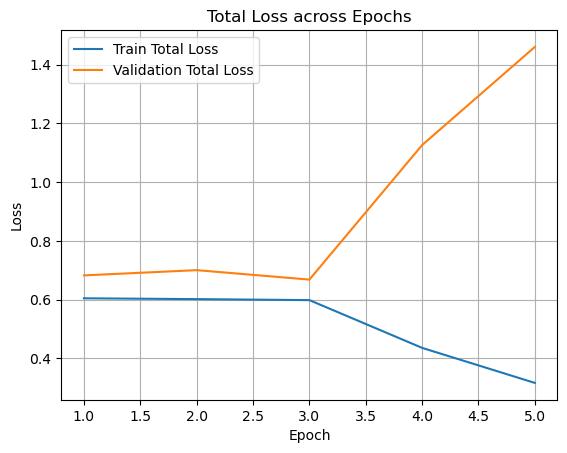

In [4030]:
# Plot loss over epochs
plt.figure()
plt.plot(range(1, len(train_loss)+1), train_loss, label='Train Total Loss')
plt.plot(range(1, len(val_loss)+1), val_loss, label='Validation Total Loss')
plt.title('Total Loss across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

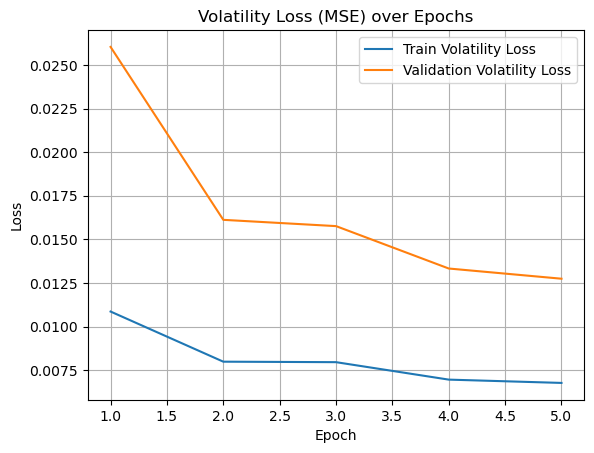

In [4031]:
# Plot volatility MSE over epochs
plt.figure()
plt.plot(range(1, len(train_vol_loss)+1),train_vol_loss, label='Train Volatility Loss')
plt.plot(range(1, len(val_vol_loss)+1),val_vol_loss, label='Validation Volatility Loss')
plt.title('Volatility Loss (MSE) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

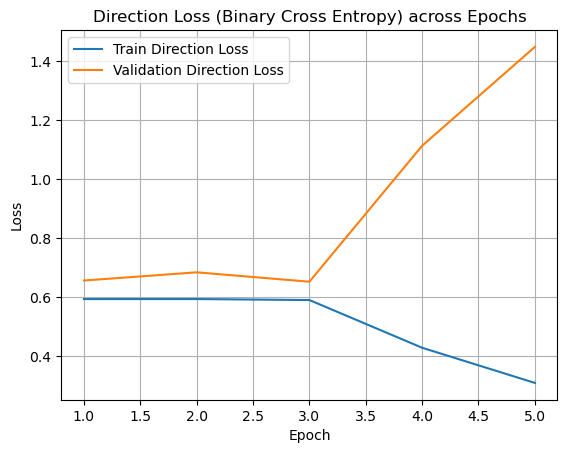

In [4032]:
# PLot Binary Cross Entropy Loss
plt.figure()
plt.plot(range(1, len(train_dir_loss)+1),train_dir_loss, label='Train Direction Loss')
plt.plot(range(1, len(val_dir_loss)+1),val_dir_loss, label='Validation Direction Loss')
plt.title('Direction Loss (Binary Cross Entropy) across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

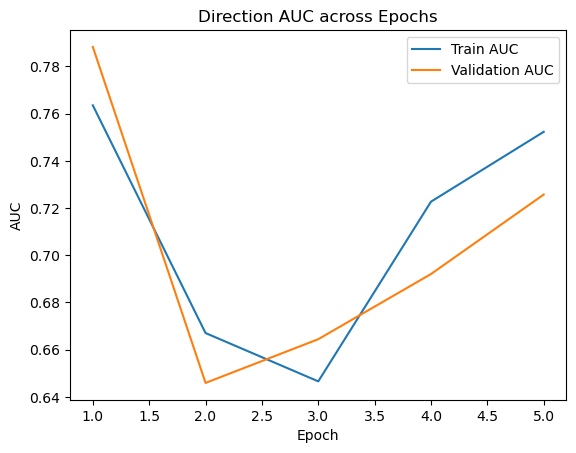

In [4033]:
# Plot direction AUC across epochs 
plt.figure()
plt.plot(range(1, len(train_auc)+1),train_auc, label='Train AUC')
plt.plot(range(1, len(val_auc)+1),val_auc, label='Validation AUC')
plt.title('Direction AUC across Epochs')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.show()

In [4034]:
all_preds = []
all_targets = []
all_probs = []
test_metrics = evaluate(model2, test_loader, mse_loss, bce_loss)

In [4035]:
print("Test set Volatility Evaluation:")
print(f"Test MSE: {test_metrics['vol_loss']:.4f}")
print(f"Test MAE: {test_metrics['mae']:.4f}")

print("Test set Direction Evaluation:")
print(f"Test AUC: {test_metrics['auc']:.4f}")

Test set Volatility Evaluation:
Test MSE: 0.0026
Test MAE: 0.0389
Test set Direction Evaluation:
Test AUC: 0.5358


Confusion Matrix:
[[153  10]
 [ 86  44]]


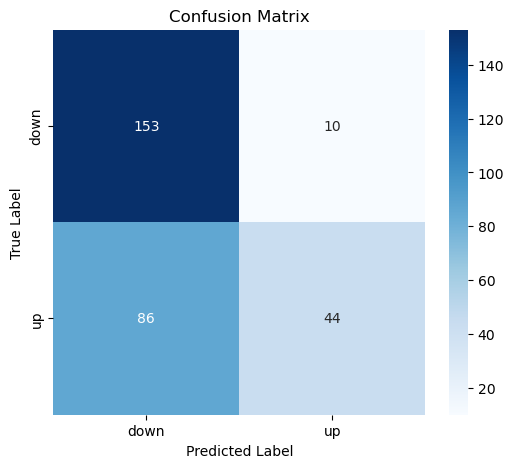

In [4036]:
# Convert probabilities to 0/1
y_dir_pred_class = (np.array(all_preds) > threshold).astype(int)

# print(np.unique(yd_test))

# Confusion matrix
cm = confusion_matrix(yd_test, y_dir_pred_class)
print("Confusion Matrix:")
print(cm)

labels = ['down', 'up']
plt.figure(figsize=(6,5))
sns.heatmap(
   cm,
   annot=True,
   fmt="d",
   cmap="Blues",
   xticklabels=labels,
   yticklabels=labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [4037]:
# Classification Report

report = classification_report(yd_test, y_dir_pred_class, target_names=["Down", "Up"])
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

        Down       0.64      0.94      0.76       163
          Up       0.81      0.34      0.48       130

    accuracy                           0.67       293
   macro avg       0.73      0.64      0.62       293
weighted avg       0.72      0.67      0.64       293



In [4038]:
actual_vol = actual_volatility(portfolio_balanced)
print(f"Predicted Vol: {balanced_r['predicted_volatility']:.4f}, Actual Vol: {actual_vol:.4f}")
print(f"Diff in vol: {np.abs(balanced_r['predicted_volatility']-actual_vol)/balanced_r['predicted_volatility'] * 100:.4f}%")

[*********************100%***********************]  6 of 6 completed

Predicted Vol: 0.1489, Actual Vol: 0.1468
Diff in vol: 1.4156%


In [4039]:
actual_dir = actual_direction(portfolio_balanced)
print(f"Predicted Direction: {balanced_r['predicted_direction']}, Actual Direction: {actual_dir}")

[*********************100%***********************]  6 of 6 completed

Predicted Direction: ['Down'], Actual Direction: Down
